# Traffic Prediction Analysis
This notebook demonstrates the end-to-end ML pipeline for traffic congestion prediction.

This notebook covers the essential steps of an end-to-end machine learning pipeline for predicting traffic congestion. It includes data loading, exploratory data analysis (EDA), feature engineering, model training using Random Forest and Gradient Boosting, model evaluation, and finally, exporting the best model and predictions for integration into other systems.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

This cell imports all necessary libraries for data manipulation, visualization, model training, evaluation, and serialization. This includes `pandas` for data handling, `numpy` for numerical operations, `matplotlib` and `seaborn` for plotting, `sklearn` for machine learning models and utilities, `joblib` for model persistence, and `json` for data export.

## 1. Data Exploration
Load the traffic data from SQLite export and explore the features.

In [2]:
# Load data
df = pd.read_csv('traffic_data.csv')
display(df.head())
print(df.info())

,road_id,period,actual_flow,distance,capacity,condition,is_two_way
0,1,MORNING,5900,8.5,3000,7,1
1,1,EVENING,5500,8.5,3000,7,1
2,39,MORNING,2400,9.1,2700,8,1
3,35,EVENING,2800,33.4,3600,9,1
4,37,NIGHT,1200,6.4,2600,7,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   road_id      144 non-null    int64  
 1   period       144 non-null    object 
 2   actual_flow  144 non-null    int64  
 3   distance     144 non-null    float64
 4   capacity     144 non-null    int64  
 5   condition    144 non-null    int64  
 6   is_two_way   144 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 8.0+ KB
None


This section begins with loading the `traffic_data.csv` file into a pandas DataFrame. The `head()` method is used to display the first few rows, providing a quick overview of the dataset structure. The `info()` method provides a summary of the DataFrame, including the column names, non-null counts, and data types, which helps in identifying missing values and understanding data types for further processing.

In [3]:
# Summary statistics
display(df.describe())

,road_id,actual_flow,distance,capacity,condition,is_two_way
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.0
mean,24.500000,1819.020833,9.854167,2675.000000,7.625000,1.0
std,13.901753,642.855218,8.895900,561.902363,1.076611,0.0
min,1.000000,972.000000,2.100000,1800.000000,5.000000,1.0
25%,12.750000,1419.750000,4.150000,2200.000000,7.000000,1.0
50%,24.500000,1725.000000,6.850000,2600.000000,8.000000,1.0
75%,36.250000,2070.000000,11.800000,3000.000000,8.000000,1.0
max,48.000000,5900.000000,45.000000,4000.000000,10.000000,1.0


The `describe()` method generates descriptive statistics that summarize the central tendency, dispersion, and shape of a dataset's distribution for numerical columns, excluding `NaN` values. This helps in understanding the distribution and potential outliers in the data.

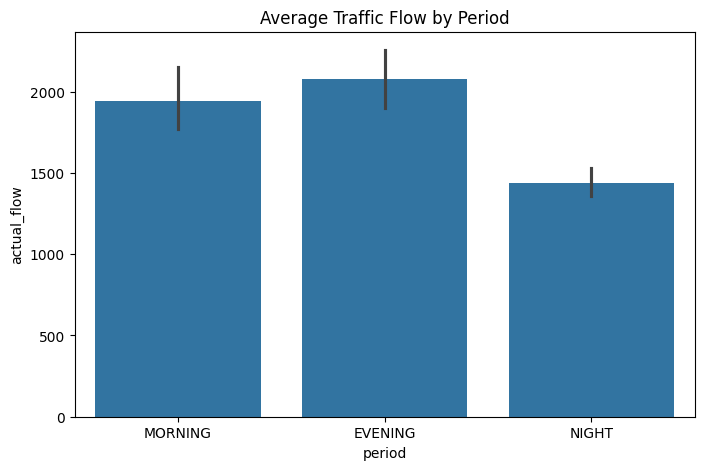

In [4]:
# Plotting traffic flow by period
plt.figure(figsize=(8, 5))
sns.barplot(x='period', y='actual_flow', data=df)
plt.title('Average Traffic Flow by Period')
plt.show()

This visualization shows the average traffic flow grouped by different periods (`MORNING`, `EVENING`, `NIGHT`). A bar plot is used to easily compare traffic flow across these periods, helping to identify peak hours.

## 2. Feature Engineering
Prepare features and target variable (congestion = actual_flow / capacity).

In [5]:
# Create target variable: Congestion
# Replace capacity=0 with NaN to avoid division by zero
df['congestion'] = df['actual_flow'] / df['capacity'].replace(0, np.nan)
df = df.dropna(subset=['congestion'])

# Encode categorical feature 'period'
df_encoded = pd.get_dummies(df, columns=['period'], drop_first=False)

# Map string conditions to numeric
if 'condition' in df.columns and df['condition'].dtype == object:
    condition_map = {'EXCELLENT': 4, 'GOOD': 3, 'FAIR': 2, 'POOR': 1}
    df_encoded['condition_num'] = df_encoded['condition'].map(condition_map).fillna(2)
else:
    df_encoded['condition_num'] = df_encoded['condition'] if 'condition' in df_encoded.columns else 2

df_encoded['is_two_way'] = df_encoded['is_two_way'].fillna(1).astype(int)

features = ['distance', 'capacity', 'condition_num', 'is_two_way']
for p in ['period_MORNING', 'period_EVENING', 'period_NIGHT']:
    if p in df_encoded.columns:
        features.append(p)

X = df_encoded[features]
y = df_encoded['congestion']

print("Features Used:", features)
display(X.head())

Features Used: ['distance', 'capacity', 'condition_num', 'is_two_way', 'period_MORNING', 'period_EVENING', 'period_NIGHT']


,distance,capacity,condition_num,is_two_way,period_MORNING,period_EVENING,period_NIGHT
0,8.5,3000,7,1,True,False,False
1,8.5,3000,7,1,False,True,False
2,9.1,2700,8,1,True,False,False
3,33.4,3600,9,1,False,True,False
4,6.4,2600,7,1,False,False,True


This section focuses on preparing the data for model training. A new target variable, `congestion`, is created by dividing `actual_flow` by `capacity`. To handle potential division by zero, `capacity` values of 0 are replaced with `NaN`, and rows with `NaN` congestion values are dropped. Categorical features like `period` are one-hot encoded using `pd.get_dummies`. The `condition` column is mapped from string values to numerical representations. `is_two_way` is also ensured to be an integer type. Finally, the feature matrix `X` and target vector `y` are defined.

## 3. Model Training
Split data and train Random Forest & Gradient Boosting models.

In [6]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

print("Models trained successfully!")

Models trained successfully!


The dataset is split into training and testing sets using `train_test_split` to evaluate model performance on unseen data. Two different regression models, `RandomForestRegressor` and `GradientBoostingRegressor`, are initialized and trained on the training data. Both models are robust ensemble methods commonly used for prediction tasks.

## 4. Evaluation
Evaluate models using RMSE, MAE, and R² score.

In [7]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    print(f"--- {name} ---")
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE:     {rmse:.4f}")
    print(f"MAE:      {mae:.4f}")
    print()
    return r2, y_pred

rf_r2, rf_pred = evaluate_model("Random Forest", rf_model, X_test, y_test)
gb_r2, gb_pred = evaluate_model("Gradient Boosting", gb_model, X_test, y_test)

--- Random Forest ---
R² Score: 0.9355
RMSE:     0.0239
MAE:      0.0105

--- Gradient Boosting ---
R² Score: 0.9381
RMSE:     0.0234
MAE:      0.0114



This section defines a function `evaluate_model` to calculate and print key regression metrics: R² score, Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE). These metrics provide a comprehensive understanding of how well the models perform. The function is then used to evaluate both the Random Forest and Gradient Boosting models on the test set, and their R² scores are stored for comparison.

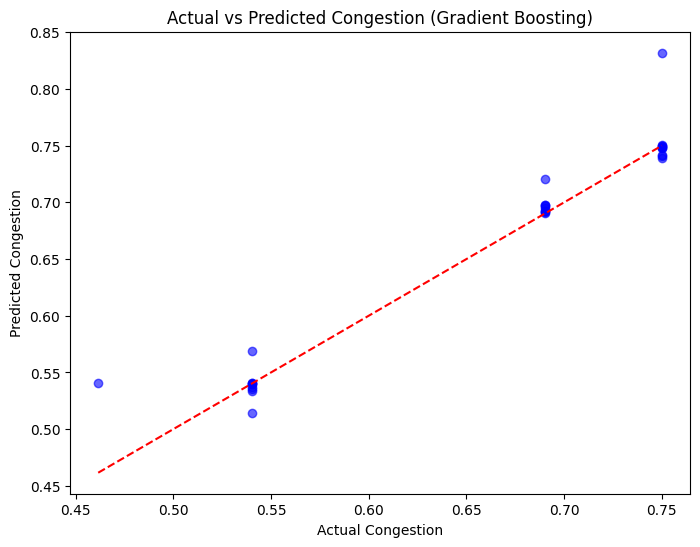

In [8]:
# Actual vs Predicted Plot (Best Model)
best_model = rf_model if rf_r2 > gb_r2 else gb_model
best_pred = rf_pred if rf_r2 > gb_r2 else gb_pred
best_name = "Random Forest" if rf_r2 > gb_r2 else "Gradient Boosting"

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, alpha=0.6, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Congestion')
plt.ylabel('Predicted Congestion')
plt.title(f'Actual vs Predicted Congestion ({best_name})')
plt.show()

This plot visualizes the actual vs. predicted congestion for the better-performing model (determined by the R² score). A scatter plot is used to show the relationship between actual and predicted values. An ideal model's predictions would lie perfectly on the `y=x` line, which is represented by the red dashed line. This plot helps in assessing the model's accuracy and identifying any biases or patterns in its errors.

## 5. Export Model & Predictions
Export the selected best model to `.joblib` and predictions for all records to `predictions.json`.

In [9]:
# Save best model
joblib.dump(best_model, 'traffic_model.joblib')
print(f"Model ({best_name}) saved to traffic_model.joblib")

Model (Gradient Boosting) saved to traffic_model.joblib


The best-performing model (either Random Forest or Gradient Boosting, based on R² score) is saved to a file named `traffic_model.joblib` using `joblib.dump`. This allows the trained model to be easily loaded and reused in other applications without retraining.

In [10]:
# Make predictions on entire dataset
df['predicted_congestion'] = best_model.predict(X)

# Format for .NET Integration
predictions = []
for _, row in df.iterrows():
    predictions.append({
        'road_id': int(row['road_id']),
        'period': str(row['period']),
        'predicted_congestion': float(row['predicted_congestion']) if not pd.isna(row['predicted_congestion']) else 0.0
    })

# Export to JSON
with open('predictions.json', 'w', encoding='utf-8') as f:
    json.dump(predictions, f, indent=4)

print(f"Exported {len(predictions)} predictions to predictions.json")

Exported 144 predictions to predictions.json


This final step involves making predictions on the entire dataset using the best model and then formatting these predictions for external integration, specifically for a .NET application. The predictions, along with `road_id` and `period`, are structured into a list of dictionaries and exported to a JSON file named `predictions.json`. This provides a standardized and easily consumable output for downstream systems.